In [9]:
# magic commands to reload custom modules
%load_ext autoreload
%autoreload 2

# magic for matplotlib
%matplotlib notebook

import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import uncertainties.unumpy as unp
from uncertainties import ufloat, ufloat_fromstr
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from mapp_tricks.peakfit import PeakFitter, sum_spectras, parse_spectrum_file, sum_spectras_matching_pattern_in_folder, sum_spectra_in_folder
from mapp_tricks.orbitos_utils import ElectrometerDataAnalyzer, BeamData
from mapp_tricks.spectrometer_calibrations import HPGeCalibration, XRayCalibration
from mapp_tricks.cross_section_analysis import GammaPeakAndTargetInfo, DataSource, do_cross_section_analysis, parse_csv, store_csv, get_activity_at_end_of_beam_with_known_cross_section, get_cross_section

from scipy.optimize import curve_fit


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Calibration using source 081025-1979021 - 19.12.2025

In [10]:
calib_source_data = pd.read_csv(('../calibration-data/raw-data/calib-2025-default/calib_source.csv'))
# convert reference_date to datetime
calib_source_data['reference_date'] = pd.to_datetime(calib_source_data['reference_date'])
# sort py peak_energy_keV
calib_source_data = calib_source_data.sort_values(by='peak_energy_keV').reset_index(drop=True)
calib_source_data.head(n=len(calib_source_data))

,radionuclide,half_life_value,half_life_uncertainty,half_life_unit,half_life_s,half_life_uncertainty_s,peak_energy_keV,peak_energy_uncertainty_keV,roi_lower_keV,roi_upper_keV,intensity,intensity_uncertainty,reference_activity_kBq,reference_activity_uncertainty_kBq,reference_date
0,Am-241,432.6000,0.6000,years,1.365182e+10,18934560.00,59.54090,0.00010,55.2064,64.5224,0.359000,0.004000,4.398,0.031,2025-11-11 12:00:00
1,Cd-109,461.9000,0.4000,days,3.990816e+07,34560.00,88.03360,0.00100,84.9824,92.0545,0.036440,0.001600,16.690,0.200,2025-11-11 12:00:00
2,Co-57,271.8100,0.0400,days,2.348438e+07,3456.00,122.06065,0.00012,118.1480,126.1960,0.856000,0.001700,1.849,0.013,2025-11-11 12:00:00
3,Co-57,271.8100,0.0400,days,2.348438e+07,3456.00,136.47356,0.00029,131.8040,141.3150,0.106800,0.000800,1.849,0.013,2025-11-11 12:00:00
4,Ce-139,137.6410,0.0200,days,1.189218e+07,1728.00,165.85750,0.00110,162.0440,170.0910,0.799000,0.000500,1.757,0.014,2025-11-11 12:00:00
5,Ba-133,10.5390,0.0060,years,3.325855e+08,189345.60,276.39890,0.00120,272.7580,280.8060,0.071600,0.000500,1.969,0.026,2025-11-11 12:00:00
6,Ba-133,10.5390,0.0060,years,3.325855e+08,189345.60,302.85080,0.00050,298.3640,306.4110,0.183400,0.001300,1.969,0.026,2025-11-11 12:00:00
7,Cr-51,27.7040,0.0040,days,2.393626e+06,345.60,320.08240,0.00040,315.6780,323.7260,0.099100,0.000100,21.280,0.150,2025-11-11 12:00:00
8,Ba-133,10.5390,0.0060,years,3.325855e+08,189345.60,356.01290,0.00070,351.5260,361.0370,0.620500,0.001000,1.969,0.026,2025-11-11 12:00:00
9,Sr-85,64.8500,0.0070,days,5.603040e+06,604.80,514.00480,0.00220,511.0920,518.9320,0.960000,0.001000,3.968,0.056,2025-11-11 12:00:00


In [11]:
# efficiency model: sum of (log(E)/E)**n terms up to n=5
def efficiency_model(E, a0, a1, a2, a3, a4, a5):
    h = np.log(E)
    return (1/E) * (
            a0 * 1 +
            a1 * h +
            a2 * h**2 +
            a3 * h**3 +
            a4 * h**4 +
            a5 * h**5)

In [ ]:

levels = np.linspace(1, 10, 10, dtype=int)

for level in levels:
    print(f'Processing calibration level: level-{level}')

    # and take roi_lower_keV and roi_upper_keV around each peak as list of tuples
    energy_ranges = list(zip(calib_source_data['roi_lower_keV'], calib_source_data['roi_upper_keV']))

    level_string = f'level-{level}'

    fitter = PeakFitter()
    res = fitter.process_file_multiple_peaks(
        filepath=f'../calibration-data/raw-data/calib-2025-default/{level_string}.txt',
        energy_ranges=energy_ranges,
        output_dir=f'../calibration-data/processed-data/calib-2025-default/{level_string}',
    )



    # since all the peaks are from the same spectra, we can extract time information from any fit result
    start_time = res[0].start_time
    real_time = res[0].real_time
    live_time = res[0].live_time

    # calculate reference activities at measurement start time
    data = calib_source_data.copy()

    ref_activities_Bq = unp.uarray(data.reference_activity_kBq, data.reference_activity_uncertainty_kBq) * 1e3  # Bq
    ref_peak_activities_Bq = ref_activities_Bq * unp.uarray(data.intensity, data.intensity_uncertainty) # Bq

    decay_time_s = start_time - data.reference_date
    # again, all peaks are from the same spectra
    decay_time_s = decay_time_s[0].total_seconds()

    half_lifes_s = unp.uarray(data.half_life_s, data.half_life_uncertainty_s)
    lambdas_s_inv = np.log(2) / half_lifes_s

    ref_peak_activities_at_measurement_start_Bq = ref_peak_activities_Bq * unp.exp(-lambdas_s_inv * decay_time_s)



    measured_peak_activities: list[ufloat] = []
    for peak_fit_result, decay_constant in zip(res, lambdas_s_inv):

        correction = (decay_constant * real_time) / (1 - unp.exp(-decay_constant * real_time)) # correction factor for decay during measurement (>1)
        mpa = (peak_fit_result.area / live_time) * correction
        # print(f'correction: {correction:.3uS}, measured peak activity: {mpa:.3uS} Bq')
        measured_peak_activities.append(mpa)

    data['measured_peak_activity_Bq'] = measured_peak_activities
    data['efficiency'] = data.measured_peak_activity_Bq / ref_peak_activities_at_measurement_start_Bq


    # fit efficiency model to data
    popt, pcov = curve_fit(
        efficiency_model,
        unp.nominal_values(data.peak_energy_keV),
        unp.nominal_values(data.efficiency),
        sigma=unp.std_devs(data.efficiency),
        absolute_sigma=True
    )


    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=unp.nominal_values(data.peak_energy_keV),
        error_x=dict(
            type='data',
            array=unp.std_devs(data.peak_energy_keV),
            visible=True
        ),
        y=unp.nominal_values(data.efficiency),
        error_y=dict(
            type='data',
            array=unp.std_devs(data.efficiency),
            visible=True
        ),
        mode='markers',
        name='Efficiency data points'
    ))
    # add fitted curve
    energy_fit = np.linspace(min(data.peak_energy_keV)*0.9, max(data.peak_energy_keV)*1.1, 1000)
    efficiency_fit = efficiency_model(energy_fit, *popt)
    fig.add_trace(go.Scatter(
        x=energy_fit,
        y=efficiency_fit,
        mode='lines',
        name='Fitted efficiency curve'
    ))
    fig.update_layout(
        title=f'HPGe Efficiency Calibration - {level_string}',
        xaxis_title='Energy (keV)',
        yaxis_title='Efficiency',
        template='plotly_white',
        margin=dict(l=40, r=40, t=40, b=40),
        height=600,
        width=900,
        )

    fig.write_image(f'../calibration-data/processed-data/calib-2025-default/{level_string}/efficiency_calibration_plot.png')
    fig.show()






Processing calibration level: level-1


peakfit - processing energy ranges:   0%|          | 0/15 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

efficienty at 140keV: 0.0912+/-0.0010


<IPython.core.display.Javascript object>

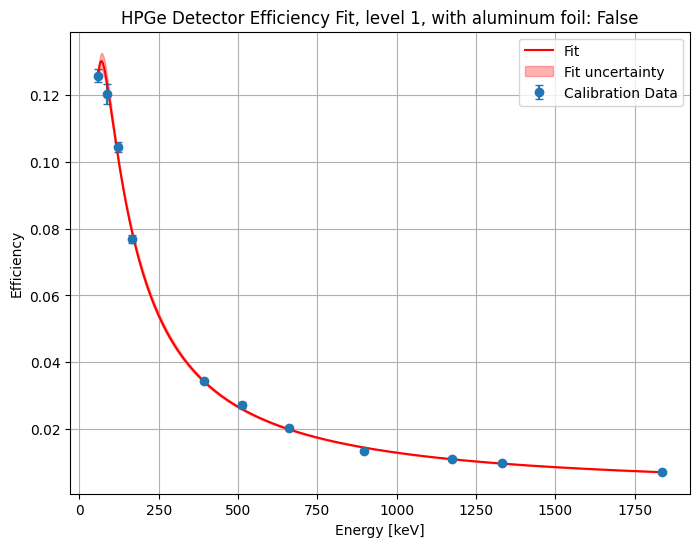

In [13]:
old_calib = HPGeCalibration(level=1, with_aluminum_foil=False)
print(f'efficienty at 140keV: {old_calib.evaluate_efficiency_at_energy(140)}')
old_calib.plot_fit()